In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import optuna

import warnings
warnings.filterwarnings('ignore') 

In [9]:
df = pd.read_csv('C:\ML\data\carsEDA.csv')

In [4]:
X = df.drop(['price_usd', "Unnamed: 0"], axis=1)
y = df['price_usd']

In [5]:
X

,manufacturer_name,model_name,transmission,color,odometer_value,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,...,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,car_age,mileage,popularity_rank,manuf_rank
0,Subaru,Other,automatic,silver,190000,gasoline,False,gasoline,2.5,universal,...,True,False,True,True,True,16,15,12666.666667,1,26
1,Subaru,Other,automatic,black,280000,gasoline,False,gasoline,2.5,universal,...,False,False,False,False,True,7,24,11666.666667,1,26
2,Subaru,Other,automatic,silver,350000,gasoline,False,gasoline,2.5,sedan,...,False,False,False,False,True,73,21,16666.666667,1,26
3,Subaru,Other,automatic,grey,179000,gasoline,False,gasoline,2.5,universal,...,True,True,True,True,True,87,15,11933.333333,1,26
4,Subaru,Other,automatic,silver,571317,gasoline,False,gasoline,2.5,universal,...,True,False,False,False,True,43,26,21973.730769,1,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28374,Chrysler,Other,automatic,red,300000,gas,True,gasoline,2.4,minivan,...,False,False,False,False,False,161,23,13043.478261,1,23
28375,Chrysler,Other,automatic,grey,179000,gasoline,False,gasoline,3.3,minivan,...,False,False,False,False,True,167,27,6629.629630,1,23
28376,Chrysler,Other,mechanical,silver,240000,diesel,False,diesel,2.5,minivan,...,True,False,True,True,True,177,20,12000.000000,1,23
28377,Chrysler,Other,automatic,blue,177000,gasoline,False,gasoline,2.4,sedan,...,False,False,False,False,False,181,22,8045.454545,1,23


In [5]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
def custom_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape}


def tune_model(model_type, X_train_proc, y_train):
    if model_type == 'Lasso':
        model = Lasso(max_iter=10000)
        params = {'alpha': [0.01, 0.1, 1, 10]}
    elif model_type == 'Ridge':
        model = Ridge()
        params = {'alpha': [0.01, 0.1, 1, 10]}
    elif model_type == 'ElasticNet':
        model = ElasticNet()
        params = {'alpha': [0.1, 1], 'l1_ratio': [0.2, 0.5, 0.8]}

    grid = GridSearchCV(model, params, cv=3).fit(X_train_proc, y_train)
    
    random = RandomizedSearchCV(model, params, n_iter=4, cv=3, random_state=42).fit(X_train_proc, y_train)
    
    def objective(trial):
        alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
        if model_type == 'ElasticNet':
            l1 = trial.suggest_float('l1_ratio', 0, 1)
            m = ElasticNet(alpha=alpha, l1_ratio=l1)
        elif model_type == 'Lasso':
            m = Lasso(alpha=alpha)
        else:
            m = Ridge(alpha=alpha)
        
        m.fit(X_train_proc, y_train)
        return mean_squared_error(y_train, m.predict(X_train_proc))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20)
    
    print(f"Best Optuna params for {model_type}: {study.best_params}")
    return grid.best_estimator_




In [8]:

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

Обучение моделей

In [9]:
models = {}

# 1. Линейная регрессия
models['Linear'] = LinearRegression().fit(X_train_proc, y_train)

# 2, 3, 4. Регуляризация с подбором
models['Lasso'] = tune_model('Lasso', X_train_proc, y_train)
models['Ridge'] = tune_model('Ridge', X_train_proc, y_train)
models['ElasticNet'] = tune_model('ElasticNet', X_train_proc, y_train)

# 5. Полиномиальная регрессия 
poly_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)),
    ('regressor', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
models['Polynomial'] = poly_pipeline


[I 2026-03-04 23:45:15,428] A new study created in memory with name: no-name-e92cf6c3-10d5-433a-8eca-99c6ae3ee725
[I 2026-03-04 23:45:20,973] Trial 0 finished with value: 2706470.07201553 and parameters: {'alpha': 0.0040571218081163945}. Best is trial 0 with value: 2706470.07201553.
[I 2026-03-04 23:45:21,632] Trial 1 finished with value: 2807983.336440062 and parameters: {'alpha': 4.066409256485143}. Best is trial 0 with value: 2706470.07201553.
[I 2026-03-04 23:45:27,262] Trial 2 finished with value: 2706469.784987375 and parameters: {'alpha': 0.0017653962262344084}. Best is trial 2 with value: 2706469.784987375.
[I 2026-03-04 23:45:28,405] Trial 3 finished with value: 2709102.577159937 and parameters: {'alpha': 0.3705896895676002}. Best is trial 2 with value: 2706469.784987375.
[I 2026-03-04 23:45:32,250] Trial 4 finished with value: 2706488.7875853768 and parameters: {'alpha': 0.02956831000677095}. Best is trial 2 with value: 2706469.784987375.
[I 2026-03-04 23:45:32,972] Trial 5 f

Best Optuna params for Lasso: {'alpha': 0.0010860834143226379}


[I 2026-03-04 23:46:41,244] A new study created in memory with name: no-name-673b464b-55e6-458d-8dba-78b2ca12953e
[I 2026-03-04 23:46:41,458] Trial 0 finished with value: 2707219.3124188655 and parameters: {'alpha': 3.8679738193567323}. Best is trial 0 with value: 2707219.3124188655.
[I 2026-03-04 23:46:41,670] Trial 1 finished with value: 2706521.3211668087 and parameters: {'alpha': 0.035374429298555894}. Best is trial 1 with value: 2706521.3211668087.
[I 2026-03-04 23:46:41,854] Trial 2 finished with value: 2706569.138187831 and parameters: {'alpha': 0.4335128440721506}. Best is trial 1 with value: 2706521.3211668087.
[I 2026-03-04 23:46:42,070] Trial 3 finished with value: 2706549.3041134984 and parameters: {'alpha': 0.4605943042833545}. Best is trial 1 with value: 2706521.3211668087.
[I 2026-03-04 23:46:42,310] Trial 4 finished with value: 2706505.1680007135 and parameters: {'alpha': 0.005192827685783991}. Best is trial 4 with value: 2706505.1680007135.
[I 2026-03-04 23:46:42,507] 

Best Optuna params for Ridge: {'alpha': 0.005192827685783991}


[I 2026-03-04 23:46:51,013] A new study created in memory with name: no-name-0211e4f6-9874-48a9-af62-c62a85a0864e
[I 2026-03-04 23:46:51,082] Trial 0 finished with value: 8859650.105013514 and parameters: {'alpha': 7.349323753453042, 'l1_ratio': 0.3008295438008991}. Best is trial 0 with value: 8859650.105013514.
[I 2026-03-04 23:46:55,802] Trial 1 finished with value: 2719685.6260987115 and parameters: {'alpha': 0.004043707520910258, 'l1_ratio': 0.6780571884650943}. Best is trial 1 with value: 2719685.6260987115.
[I 2026-03-04 23:46:56,258] Trial 2 finished with value: 2894849.325279833 and parameters: {'alpha': 0.04030361856900626, 'l1_ratio': 0.41838675065557673}. Best is trial 1 with value: 2719685.6260987115.
[I 2026-03-04 23:46:56,468] Trial 3 finished with value: 3263945.7394415345 and parameters: {'alpha': 0.13694954603757326, 'l1_ratio': 0.14516966752693272}. Best is trial 1 with value: 2719685.6260987115.
[I 2026-03-04 23:46:56,686] Trial 4 finished with value: 3164733.7935442

Best Optuna params for ElasticNet: {'alpha': 0.0010065091158794886, 'l1_ratio': 0.9886989457696619}


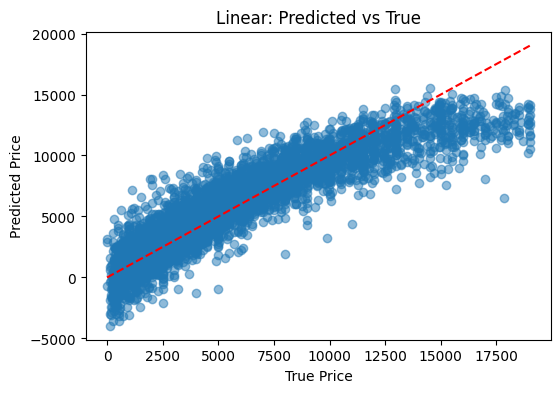

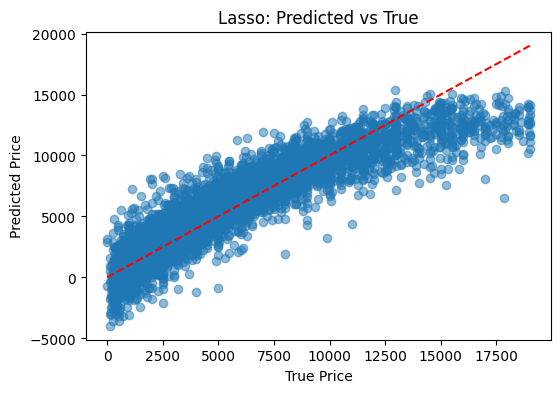

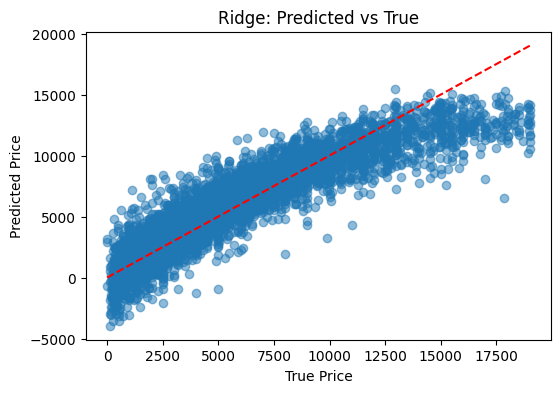

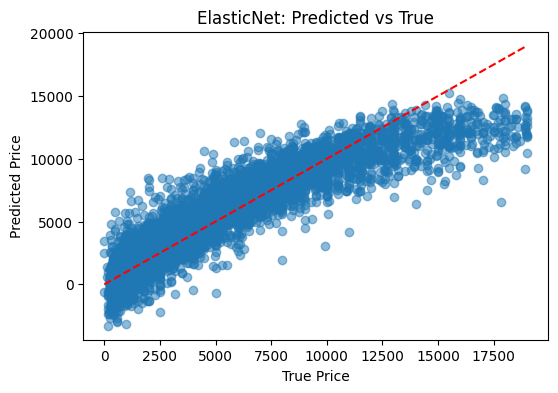

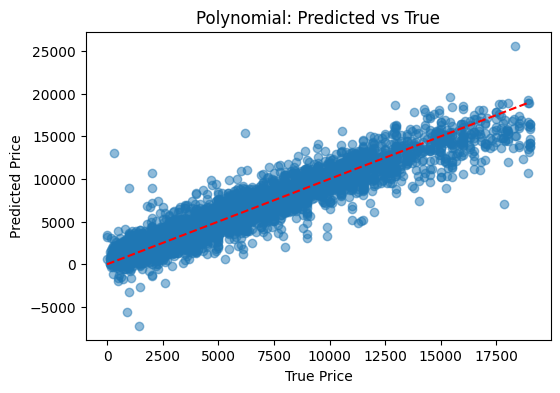

In [10]:

results = []

for name, model in models.items():
    if name == 'Polynomial':
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_proc)
    
    # Метрики Sklearn
    sk_metrics = {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred)
    }
    
    # Свои метрики
    my_metrics = custom_metrics(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R2 (SK)": sk_metrics["R2"],
        "R2 (My)": my_metrics["R2"],
        "MAE (SK)": sk_metrics["MAE"],
        "MAE (My)": my_metrics["MAE"]
    })

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"{name}: Predicted vs True")
    plt.xlabel("True Price")
    plt.ylabel("Predicted Price")
    plt.show()



In [11]:
results_df = pd.DataFrame(results)
print("\nСравнение метрик (Sklearn vs Собственная реализация):")
print(results_df)


Сравнение метрик (Sklearn vs Собственная реализация):
        Model   R2 (SK)   R2 (My)     MAE (SK)     MAE (My)
0      Linear  0.838419  0.838419  1212.438473  1212.438473
1       Lasso  0.838429  0.838429  1212.273210  1212.273210
2       Ridge  0.838477  0.838477  1212.165907  1212.165907
3  ElasticNet  0.828633  0.828633  1239.824082  1239.824082
4  Polynomial  0.899151  0.899151   917.921088   917.921088
